In [1]:
import pandas as pd
import os
import re

DATA_DIR = os.path.dirname(os.path.abspath('mystocks.ipynb'))
DATA_DIR_DATA = DATA_DIR + "/accounts"
from dotenv import dotenv_values

_env     = dotenv_values(os.path.join(DATA_DIR, '.env'))
acc_names = {k.replace('ACC_', ''): v for k, v in _env.items() if k.startswith('ACC_')}

accounts = {}  # account_number (str) -> DataFrame(index=Symbol, cols=[Quantity, Current Price])
acc = ['618',"370",'472',"137","133"]

def clean_num(val):
    """Strip $, commas, % from a value and return float or NaN."""
    if pd.isna(val):
        return float('nan')
    s = str(val).strip().replace('$', '').replace(',', '').replace('%', '')
    try:
        return float(s)
    except ValueError:
        return float('nan')

exclude = ["earnings.csv","historical.csv", "portfolio.csv",
           "sectors.csv","file_clean.csv","History_for_Account_226998197.csv",
            "History_for_Account_236369828.csv" ]
for filename in sorted(os.listdir(DATA_DIR_DATA), key=lambda f: os.path.getmtime(os.path.join(DATA_DIR_DATA, f))):
    if filename in exclude:
        continue
    filepath = os.path.join(DATA_DIR_DATA, filename)
    print("try",filepath)
    if not filename.endswith('.csv'):
        if not filename.endswith('.xlsx'):
            continue
        else:
            try:
                cols = pd.read_excel(filepath, nrows=1, skiprows=11,index_col=0)
                cols = cols.iloc[0].to_list()
                df = pd.read_excel(filepath,header=12, sheet_name=0, index_col=0, names =cols)
                acct_num = str(int(df['Account Number'].dropna().iloc[0][-4:]))

                #
                df['Quantity']      = pd.to_numeric(df['Quantity'], errors='coerce')
                df['Current_Price'] = df['Price'].apply(clean_num)
                df['Market_Value'] = df['Market Value'].apply(clean_num)
                result = result = (
                    df[['Security ID', 'Quantity', 'Current_Price','Market_Value']]
              .dropna(subset=['Market_Value'])
                      .set_index('Security ID').rename(index={'PGC': 'cash', 'USD999997': 'cash'})
                )
                accounts[acct_num] = result
    
            except Exception as e:
                print("no excel:",e)
                continue
            continue

    
 
    with open(filepath, 'r') as f:
        first_line = f.readline().strip()

    # ── Format A-Multi: Schwab All-Accounts combined export ─────────────────────
    if first_line.startswith('"Positions for All-Accounts') or first_line.startswith('"Positions for all'):
        with open(filepath, 'r') as f:
            raw_lines = [l.rstrip(',\n') + '\n' for l in f.readlines()]

        NON_EQUITY_AM = {'Futures Cash', 'Futures Positions Market Value',
                         'Positions Total', '--', 'Cash and Money Market'}

        current_acct  = None
        section_lines = []

        def _flush_schwab_section(acct, lines):
            if not acct or not lines:
                return
            try:
                import io as _io
                block = _io.StringIO(''.join(lines))
                df = pd.read_csv(block, header=0)
                df = df.loc[:, df.columns.notna() & (df.columns.str.strip() != '')]
                df.columns = df.columns.str.strip()
                df = df[df['Symbol'].notna() & ~df['Symbol'].isin(NON_EQUITY_AM)]
                df['Quantity']     = pd.to_numeric(
                    df['Qty (Quantity)'].astype(str).str.replace(',', '', regex=False),
                    errors='coerce')
                df['Market_Value'] = df['Mkt Val (Market Value)'].apply(clean_num)
                df['Current_Price']= df['Market_Value'] / df['Quantity']
                result = (df[['Symbol','Quantity','Market_Value','Current_Price']]
                          .dropna(subset=['Market_Value'])
                          .set_index('Symbol')
                          .rename(index={'Cash & Cash Investments': 'cash'}))
                accounts[acct] = result
                print(acct, 'schwab/td all-accts', acc_names.get(acct, 'found none'))
            except Exception as e:
                print(f'all-accts section {acct} error: {e}')

        for line in raw_lines[1:]:          # skip the "Positions for All-Accounts" header
            stripped = line.strip().strip('"')
            acct_m   = re.search(r'\.\.\.(\w+)', stripped)
            if acct_m and not stripped.startswith('Symbol') and 'Positions' not in stripped:
                _flush_schwab_section(current_acct, section_lines)
                current_acct  = acct_m.group(1)
                section_lines = []
            elif stripped.startswith('"Symbol"') or stripped.startswith('Symbol'):
                section_lines = [line]      # start fresh with this header row
            elif stripped and current_acct:
                section_lines.append(line)

        _flush_schwab_section(current_acct, section_lines)

    # ── Format A: Schwab/TD  "Positions for account ..." ──────────────────────
    elif first_line.startswith('"Positions for account'):
        match = re.search(r'\.\.(\w+)', first_line)
        
        acct_num = match.group(1) if match else filename
        print(acct_num, "schawb/td", acc_names.get(acct_num,"found none"))

        df = pd.read_csv(filepath, skiprows=2, header=0)
        # Drop the spurious empty trailing column produced by the trailing comma
        df = df.loc[:, df.columns.notna() & (df.columns.str.strip() != '')]
        df.columns = df.columns.str.strip()

        NON_EQUITY = {
            #'Cash & Cash Investments', 
            'Futures Cash',
            'Futures Positions Market Value', 'Positions Total', '--'
        }
        df = df[df['Symbol'].notna() & ~df['Symbol'].isin(NON_EQUITY)]
        
        df['Quantity']      = pd.to_numeric(
            df['Qty (Quantity)'].astype(str).str.replace(',', '', regex=False),
            errors='coerce'
        )
        df['Current_Price'] = (
            df['Mkt Val (Market Value)']
              .apply(clean_num)
            / df['Quantity']
        )
        df['Market_Value'] = (
            df['Mkt Val (Market Value)']
              .apply(clean_num)
            
        )
        result = (
            df[['Symbol', 'Quantity',"Market_Value", 'Current_Price']]
              .dropna(subset=[ 'Market_Value'])
              .set_index('Symbol').rename(index={'Cash & Cash Investments': 'cash'})
        )
        accounts[acct_num] = result
        df.rename(index={'Cash & Cash Investments':"cash"}, inplace=True)

    # ── Format B: ETRADE PortfolioDownload  (Account Summary header) ────────
    elif first_line.strip('"') == 'Account Summary':
        with open(filepath, 'r') as f:
            raw = f.readlines()

        # Account number is the last numeric segment on line 3 (index 2)
        match = re.search(r'-(\d+)', raw[2])
        acct_num = match.group(1) if match else filename
        print(acct_num, "etrade", acc_names.get(acct_num,"found none"))
        # Locate the data-header row that begins with "Symbol,Last Price"
        header_idx = next(
            (i for i, line in enumerate(raw)
             if line.strip().startswith('Symbol,Last Price')),
            None
        )
        if header_idx is None:
            print(f'WARNING: could not find data header in {filename}')
            continue

        # Strip trailing commas before parsing (E*Trade exports often have them)
        clean_lines = [line.rstrip(',\n') + '\n' for line in raw]
        with open(os.path.join(DATA_DIR, 'file_clean.csv'), 'w') as f:
            f.writelines(clean_lines)
        clean_path = os.path.join(DATA_DIR, 'file_clean.csv')

        try:
            df = pd.read_csv(clean_path, skiprows=header_idx, header=0, skipfooter=5, engine='python')
        except Exception as e:
            print(e)
            continue
        df.columns = df.columns.str.strip()
        
        df = df[df['Symbol'].notna() & ~df['Symbol'].isin([ 'TOTAL', ''])]
        try:
            df['Quantity']      = pd.to_numeric(df['Quantity'], errors='coerce')
        except:
            "Qty #"
            df['Quantity']      = pd.to_numeric(df["Qty #"], errors='coerce')
        df['Current_Price'] = pd.to_numeric(df['Last Price $'], errors='coerce')
        df['Market_Value'] = pd.to_numeric(df['Value $'], errors='coerce')

        result = (
            df[['Symbol', 'Quantity', 'Current_Price','Market_Value']]
              .dropna(subset=['Market_Value'])
              .set_index('Symbol').rename(index={'CASH': 'cash'})
        )
        accounts[acct_num] = result

    # ── Format C: Fidelity Portfolio_Positions  (Account Number column) ───────
    else:
        try:
            with open(filepath, 'r') as f:
                lines = f.readlines()

            lines = [line.rstrip(',\n') + '\n' for line in lines]

            with open('file_clean.csv', 'w') as f:
                f.writelines(lines)
            filepath = os.path.join(DATA_DIR, "file_clean.csv")
            df = pd.read_csv(filepath, header=0)
        except Exception as e:
            print(f'WARNING: could not read {filename}: {e}')
            continue

        if 'Account Number' not in df.columns:
            print(f'WARNING: unrecognised format in {filename}, skipping')
            continue

        df.columns = df.columns.str.strip()
        
        df['Quantity']      = pd.to_numeric(df['Quantity'], errors='coerce')
        df['Current_Price'] = df['Last Price'].apply(clean_num)
        df['Market_Value'] = df['Current Value'].apply(clean_num)

        df = df[pd.to_numeric(df['Account Number'], errors='coerce').notna()]
        for raw_acct, grp in df.groupby('Account Number'):
            acct_num = str(int(str(raw_acct).strip()[-4:]))
            print(acct_num, "fid", acc_names.get(acct_num, "found none"))
            result = (
                grp[['Symbol', 'Quantity', 'Current_Price', 'Market_Value']]
                  .dropna(subset=['Market_Value'])
                  .set_index('Symbol').rename(index={'SPAXX**': 'cash'})
            )
            accounts[acct_num] = result
    


# ── Print all accounts sorted by account number ───────────────────────────────
for acct in sorted(accounts):
    print(f"\n{'='*55}")
    print(f" Account: {acct}")
    print(f"{'='*55}")
    print(accounts[acct].to_string(float_format='%.4f'))


try /home/ai1/Documents/fiData/accounts/Designated Bene Individual-Positions-2026-06-04-154055.csv
137 schawb/td cs_big
try /home/ai1/Documents/fiData/accounts/Designated Bene Individual-Positions-2026-06-04-161722.csv
137 schawb/td cs_big
try /home/ai1/Documents/fiData/accounts/Rollover IRA-Positions-2026-06-04-161731.csv
370 schawb/td cs_roll_2
try /home/ai1/Documents/fiData/accounts/Designated Bene Individual-Positions-2026-06-04-161738.csv
472 schawb/td cs_mid
try /home/ai1/Documents/fiData/accounts/Rollover IRA-Positions-2026-06-04-161745.csv
618 schawb/td cs_roll_1
try /home/ai1/Documents/fiData/accounts/Contributory-Positions-2026-06-04-161752.csv
133 schawb/td cs_small
try /home/ai1/Documents/fiData/accounts/Portfolio_Positions_Jun-04-2026.csv
8197 fid fid_roth
9828 fid fid_ira
try /home/ai1/Documents/fiData/accounts/Portfolio_Positions_Jun-04-2026(1).csv
8197 fid fid_roth
try /home/ai1/Documents/fiData/accounts/Portfolio_Positions_Jun-04-2026(2).csv
9828 fid fid_ira
try /home/

In [2]:
# Merge all accounts into one DataFrame, grouped by Symbol
all_rows = pd.concat(accounts.values())
all_rows.index.name = 'Symbol'   # normalize across CSV and xlsx formats

cash_rows   = all_rows[all_rows.index == 'cash']
equity_rows = all_rows[all_rows.index != 'cash']

# Flag any symbols where price differs across accounts (tolerance: $0.01)
price_check = equity_rows.groupby('Symbol')['Current_Price'].agg(['min', 'max'])
price_mismatches = price_check[abs(price_check['max'] - price_check['min']) > 0.01]
if not price_mismatches.empty:
    print("⚠ Price mismatches across accounts (same symbol, different price):")
    print(price_mismatches.to_string())
    print()

# Equity: sum Quantity & Market_Value, mean Current_Price (consistent across accounts)
combined = (
    equity_rows
    .groupby('Symbol')
    .agg(
        Quantity      =('Quantity',      'sum'),
        Current_Price =('Current_Price', 'mean'),
        Market_Value  =('Market_Value',  'sum'),
    )
    .sort_index()
)

# Cash: sum Market_Value only (Quantity/Price are unreliable across formats)
total_cash = cash_rows['Market_Value'].sum()
cash_combined = pd.DataFrame(
    {'Quantity': [float('nan')], 'Current_Price': [1.0], 'Market_Value': [total_cash]},
    index=pd.Index(['cash'], name='Symbol')
)

combined = pd.concat([combined, cash_combined])
combined.rename(index={'BRK/B':"BRK-B"})
combined


⚠ Price mismatches across accounts (same symbol, different price):
              min          max
Symbol                        
AMZN     245.3200   253.790000
AVGO     406.9600   418.910000
EPOL      39.7250    40.360000
EUSA     112.5500   113.360000
EWI       60.5500    60.625333
EWP       57.5000    59.185111
EWY      219.9400   220.200000
FEZ       68.4200    70.010000
GDE       64.0500    64.130000
GOOGL    367.1300   368.340000
KORU    1096.4400  1103.140000
META     576.0100   627.570000
MU      1132.8700  1144.150000
PPA      173.5300   175.185333
QQQ      739.8000   740.610000
QUAL     216.3500   217.330000
RSP      210.7200   210.830000
SOXL     280.3200   280.440000
SPY      746.7299   757.090000
SPYG     119.4700   121.190000
WFC       83.0050    83.215000
XOM      137.1900   152.040000



,Quantity,Current_Price,Market_Value
Symbol,,,
AAPL,106.0,297.829811,31569.96
ADI,4.0,433.380000,1733.52
AMKR,30.0,89.985000,2699.55
AMZN,184.0,248.143333,45647.08
AVGO,40.0,412.935000,16517.40
...,...,...,...
WMT,60.0,116.980000,7018.80
XLP,30.0,82.040000,2461.20
XOM,160.0,144.615000,22247.40


In [3]:
# ── Trade History & Cost Basis ────────────────────────────────────────────────
import io, re
from datetime import date as _date

BUYSELL_DIR = os.path.join(DATA_DIR, 'buysell')
CUTOFF      = pd.Timestamp('2023-01-01')
DEFAULT_BUY = pd.bdate_range('2023-01-01', periods=1)[0]  # first trading day on/after Jan 1

_OCC_RE = re.compile(r'^[A-Z]{1,6}\d{6}[CP]\d+$')

def _is_option(sym):
    return bool(_OCC_RE.match(str(sym).strip()))

def _parse_action(action_str):
    s = str(action_str).upper()
    if 'BOUGHT' in s or 'REINVESTED' in s:
        return 'BUY'
    if 'SOLD' in s:
        return 'SELL'
    return None

# ── 1. Transaction history files ──────────────────────────────────────────────
tx_rows = []

for fn in sorted(os.listdir(BUYSELL_DIR)):
    if not fn.endswith('.csv'):
        continue
    fp = os.path.join(BUYSELL_DIR, fn)
    with open(fp, 'r', encoding='utf-8-sig') as f:
        lines = f.readlines()
    first = lines[0].strip() if lines else ''
    if first.startswith('"Realized Gain/Loss') or first == 'Account Summary':
        continue
    hdr_idx = next((i for i, l in enumerate(lines) if 'Run Date' in l), None)
    if hdr_idx is None:
        continue
    clean = [l.rstrip(',\n') + '\n' for l in lines]
    try:
        df = pd.read_csv(io.StringIO(''.join(clean[hdr_idx:])), header=0)
    except Exception as e:
        print(f'history skip {fn}: {e}')
        continue
    df.columns = df.columns.str.strip()
    multi_acct = 'Account Number' in df.columns
    for _, row in df.iterrows():
        sym = str(row.get('Symbol', '')).strip()
        if not sym or sym == 'nan' or _is_option(sym):
            continue
        action = _parse_action(row.get('Action', ''))
        if not action:
            continue
        dt = pd.to_datetime(row.get('Run Date'), errors='coerce')
        if pd.isna(dt) or dt < CUTOFF:
            continue
        qty   = abs(pd.to_numeric(row.get('Quantity', 0), errors='coerce') or 0)
        price = pd.to_numeric(row.get('Price ($)', None), errors='coerce')
        if multi_acct:
            acct = str(row.get('Account Number', '')).strip()[-4:]
        else:
            m = re.search(r'(\d{9,})', fn)
            acct = m.group(1)[-4:] if m else fn
        tx_rows.append(dict(Symbol=sym, Date=dt, Action=action,
                            Quantity=qty, Price=price, Account=acct))

# ── 1b. xlsx history files (E*Trade "History" format) ────────────────────────
for fn in sorted(os.listdir(BUYSELL_DIR)):
    if not fn.endswith('.xlsx'):
        continue
    fp = os.path.join(BUYSELL_DIR, fn)
    try:
        meta = pd.read_excel(fp, header=None, nrows=6)
        acct_raw = str(meta.iloc[4, 1]).strip()          # "Account: XRA580898"
        acct_id  = re.sub(r'[^A-Z0-9]', '', acct_raw)   # "XRA580898"
        acct     = acct_id[-4:]                           # last 4 chars as key

        df = pd.read_excel(fp, skiprows=6, header=0)
        df.columns = df.columns.str.strip()
    except Exception as e:
        print(f'xlsx skip {fn}: {e}')
        continue

    for _, row in df.iterrows():
        desc = str(row.get('Activity Description', ''))
        if 'Buy' in desc:
            action = 'BUY'
        elif 'Sell' in desc:
            action = 'SELL'
        else:
            continue

        sym = str(row.get('Security ID', '')).strip()
        if not sym or sym == 'nan' or _is_option(sym):
            continue

        dt = pd.to_datetime(row.get('Trade Date') or row.get('Date'), errors='coerce')
        if pd.isna(dt) or dt < CUTOFF:
            continue

        qty   = abs(pd.to_numeric(row.get('Quantity', 0), errors='coerce') or 0)
        price = pd.to_numeric(row.get('Price', None), errors='coerce')
        tx_rows.append(dict(Symbol=sym, Date=dt, Action=action,
                            Quantity=qty, Price=price, Account=acct))


tx_df = (pd.DataFrame(tx_rows) if tx_rows
         else pd.DataFrame(columns=['Symbol','Date','Action','Quantity','Price','Account']))
if not tx_df.empty:
    tx_df['Date'] = pd.to_datetime(tx_df['Date'])

# ── 2. Realized gain/loss lot detail files ────────────────────────────────────
lot_rows = []

for fn in sorted(os.listdir(BUYSELL_DIR)):
    if not fn.endswith('.csv'):
        continue
    fp = os.path.join(BUYSELL_DIR, fn)
    with open(fp, 'r', encoding='utf-8-sig') as f:
        first = f.readline()
    if not first.strip().startswith('"Realized Gain/Loss'):
        continue

    # Multi-account files have account-section headers between data blocks;
    # parse line-by-line to handle both single- and multi-account exports.
    import csv as _csv
    col_names = None
    try:
        with open(fp, 'r', encoding='utf-8-sig') as _f:
            reader = _csv.reader(_f)
            for i, row in enumerate(reader):
                if i == 0:          # file-level header line
                    continue
                if not row or not row[0].strip():
                    continue
                cell0 = row[0].strip().strip('"')
                # Symbol header row → set column names for this section
                if cell0 == 'Symbol':
                    col_names = [c.strip().strip('"') for c in row]
                    continue
                # Account-name header or "no transactions" message → skip
                if re.search(r'\.\.\.\w+', cell0) or 'no transactions' in cell0.lower():
                    continue
                if col_names is None:
                    continue
                row_dict = dict(zip(col_names, row))
                sym = row_dict.get('Symbol', '').strip().strip('"')
                if not sym or sym == 'nan' or _is_option(sym):
                    continue
                opened = pd.to_datetime(row_dict.get('Opened Date'), errors='coerce')
                closed  = pd.to_datetime(row_dict.get('Closed Date'),  errors='coerce')
                if pd.isna(closed):
                    continue
                if pd.isna(opened) or opened < CUTOFF:
                    opened = DEFAULT_BUY
                qty     = pd.to_numeric(str(row_dict.get('Quantity', 0)).replace(',', ''), errors='coerce')
                cost_ps = clean_num(row_dict.get('Cost Per Share'))
                proc_ps = clean_num(row_dict.get('Proceeds Per Share'))
                gl      = clean_num(row_dict.get('Gain/Loss ($)'))
                gl_pct  = clean_num(str(row_dict.get('Gain/Loss (%)', '')).replace('%', ''))
                lot_rows.append(dict(Symbol=sym, Buy_Date=opened, Sell_Date=closed,
                                     Quantity=qty, Cost_Per_Share=cost_ps,
                                     Proceeds_Per_Share=proc_ps,
                                     Gain_Loss=gl, Gain_Loss_Pct=gl_pct,
                                     Hold_Days=(closed - opened).days))
    except Exception as e:
        print(f'lot skip {fn}: {e}')
        continue

sold_df = (pd.DataFrame(lot_rows) if lot_rows else pd.DataFrame(
    columns=['Symbol','Buy_Date','Sell_Date','Quantity',
             'Cost_Per_Share','Proceeds_Per_Share','Gain_Loss','Gain_Loss_Pct','Hold_Days']))
if not sold_df.empty:
    sold_df = sold_df.drop_duplicates(
        subset=['Symbol', 'Buy_Date', 'Sell_Date', 'Quantity']).reset_index(drop=True)

# ── 3. Fallback cost basis from Fidelity position files ──────────────────────
fid_cost = {}  # symbol -> avg cost per share from brokerage export
for fn in sorted(os.listdir(DATA_DIR_DATA)):
    if not fn.endswith('.csv'):
        continue
    fp = os.path.join(DATA_DIR_DATA, fn)
    try:
        with open(fp, 'r', encoding='utf-8-sig') as f:
            lines = f.readlines()
        clean = [l.rstrip(',\n') + '\n' for l in lines]
        df_cb = pd.read_csv(io.StringIO(''.join(clean)))
        if 'Average Cost Basis' not in df_cb.columns or 'Symbol' not in df_cb.columns:
            continue
        df_cb = df_cb[['Symbol', 'Average Cost Basis']].dropna()
        for _, r in df_cb.iterrows():
            sym = str(r['Symbol']).strip()
            val = clean_num(r['Average Cost Basis'])
            if sym and not pd.isna(val):
                fid_cost[sym] = val
    except Exception:
        continue

# ── 3b. Augment combined: buy date & avg cost for current holdings ────────────
today_ts = pd.Timestamp(_date.today())

buys = tx_df[tx_df['Action'] == 'BUY'] if not tx_df.empty else pd.DataFrame()
first_buy = (buys.groupby('Symbol')['Date'].min()
             if not buys.empty else pd.Series(dtype='datetime64[ns]'))
avg_cost  = (buys.groupby('Symbol')
             .apply(lambda g: (g['Price'] * g['Quantity']).sum() / g['Quantity'].sum())
             if not buys.empty else pd.Series(dtype=float))

combined['First_Buy_Date'] = pd.to_datetime(combined.index.map(first_buy))
combined['First_Buy_Date'] = combined['First_Buy_Date'].fillna(DEFAULT_BUY)
combined['Days_Held']      = (today_ts - combined['First_Buy_Date']).dt.days.astype('Int64')
combined['Avg_Buy_Price']  = combined.index.map(avg_cost)

# Fill missing avg cost from brokerage position file
missing_mask = combined['Avg_Buy_Price'].isna() & (combined.index != 'cash')
combined.loc[missing_mask, 'Avg_Buy_Price'] = combined.loc[missing_mask].index.map(
    lambda s: fid_cost.get(s, float('nan'))
)

# ── 4. Print: current holdings with entry dates ───────────────────────────────
hold_out = combined[combined.index != 'cash'][
    ['First_Buy_Date', 'Days_Held', 'Avg_Buy_Price', 'Current_Price', 'Market_Value']
].copy()
hold_out['Return_%'] = (
    (combined['Current_Price'] / hold_out['Avg_Buy_Price'] - 1) * 100
).round(2)
hold_out = hold_out.sort_values('First_Buy_Date')

print(f'\n{"═"*72}')
print('  Current Holdings — Entry Dates & Return vs Avg Cost')
print(f'{"═"*72}')
print(hold_out.to_string(float_format='%.2f'))

# ── 5. Print: closed positions summary ────────────────────────────────────────
if not sold_df.empty:
    summ = (sold_df.groupby('Symbol')
            .agg(Lots      =('Quantity',      'count'),
                 Total_Qty =('Quantity',      'sum'),
                 Total_GL  =('Gain_Loss',     'sum'),
                 Avg_GL_Pct=('Gain_Loss_Pct', 'mean'),
                 First_Buy =('Buy_Date',      'min'),
                 Last_Sell =('Sell_Date',     'max'),
                 Avg_Hold  =('Hold_Days',     'mean'))
            .sort_values('Total_GL', ascending=False))
    summ['Avg_Hold']  = summ['Avg_Hold'].round(0).astype(int)
    summ['Total_GL']  = summ['Total_GL'].round(2)
    summ['Avg_GL_Pct']= summ['Avg_GL_Pct'].round(2)
    print(f'\n{"═"*72}')
    print('  Closed Positions — Realized Gain/Loss (2023+)')
    print(f'{"═"*72}')
    print(summ.to_string())



════════════════════════════════════════════════════════════════════════
  Current Holdings — Entry Dates & Return vs Avg Cost
════════════════════════════════════════════════════════════════════════
       First_Buy_Date  Days_Held  Avg_Buy_Price  Current_Price  Market_Value  Return_%
Symbol                                                                                
AAPL       2023-01-02       1265            NaN         297.83      31569.96       NaN
QUAL       2023-01-02       1265            NaN         216.84       8457.25       NaN
QTOP       2023-01-02       1265            NaN          38.80       1939.75       NaN
QCOM       2023-01-02       1265            NaN         225.17       2251.70       NaN
PPA        2023-01-02       1265            NaN         174.36       5230.73       NaN
POCT       2023-01-02       1265            NaN          46.33       2084.85       NaN
PINS       2023-01-02       1265            NaN          20.46        204.55       NaN
PH         2023-

/tmp/ipykernel_443976/3677520154.py:204: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g['Price'] * g['Quantity']).sum() / g['Quantity'].sum())


In [4]:
# ── Capital Tracking & Cash-Adjusted Performance ──────────────────────────────

# ── 1. Annual net capital deployment ─────────────────────────────────────────
# Signed cash flow per transaction: BUY = money out (-), SELL = money in (+)
if not tx_df.empty and 'Price' in tx_df.columns:
    cf = tx_df.copy()
    cf = cf[cf['Price'].notna() & cf['Quantity'].notna()]
    cf['Cash_Flow'] = cf.apply(
        lambda r: -(r['Price'] * r['Quantity']) if r['Action'] == 'BUY'
                  else  (r['Price'] * r['Quantity']), axis=1)
    cf['Year'] = cf['Date'].dt.year

    annual_deploy = (cf.groupby('Year')
                     .agg(Bought=('Cash_Flow', lambda x: -x[x < 0].sum()),
                          Sold  =('Cash_Flow', lambda x:  x[x > 0].sum()))
                     .assign(Net_Deployed=lambda d: d['Bought'] - d['Sold'])
                    )
else:
    annual_deploy = pd.DataFrame(columns=['Bought','Sold','Net_Deployed'])

# Annual realized G/L (by sell year)
if not sold_df.empty:
    annual_gl = (sold_df.assign(Year=sold_df['Sell_Date'].dt.year)
                        .groupby('Year')['Gain_Loss'].sum().round(2))
else:
    annual_gl = pd.Series(dtype=float)

annual = annual_deploy.copy()
annual['Realized_GL'] = annual.index.map(annual_gl).round(2)
annual[['Bought','Sold','Net_Deployed']] = annual[['Bought','Sold','Net_Deployed']].round(2)

print(f'\n{"═"*70}')
print('  Annual Capital Activity  (proxy: net securities purchased)')
print(f'{"═"*70}')
print(annual.to_string(float_format='${:,.0f}'.format))

# ── 2. Current holdings: cost basis vs market value ───────────────────────────
eq = combined[combined.index != 'cash'].copy()
eq['Cost_Basis'] = (eq['Avg_Buy_Price'] * eq['Quantity']).round(2)
eq['Unreal_GL']  = (eq['Market_Value'] - eq['Cost_Basis']).round(2)
eq['Unreal_GL%'] = ((eq['Unreal_GL'] / eq['Cost_Basis']) * 100).round(2)

cost_totals = eq[['Cost_Basis','Market_Value','Unreal_GL']].sum()
total_cost  = cost_totals['Cost_Basis']
total_mv    = cost_totals['Market_Value']
total_ugl   = cost_totals['Unreal_GL']

print(f'\n{"═"*70}')
print('  Current Holdings — Cost Basis vs Market Value')
print(f'{"═"*70}')
disp = eq[['Cost_Basis','Market_Value','Unreal_GL','Unreal_GL%']].sort_values('Unreal_GL%', ascending=False)
print(disp.to_string(float_format='%.2f'))
print(f'\n  {"TOTAL":<20} Cost: ${total_cost:>12,.2f}   MktVal: ${total_mv:>12,.2f}   Unreal G/L: ${total_ugl:>12,.2f}')

# ── 3. Overall return on invested capital ─────────────────────────────────────
total_realized = annual_gl.sum() if not annual_gl.empty else 0.0
total_gl       = total_ugl + total_realized
# Denominator = cost basis of current holdings + cost basis of closed positions
if not sold_df.empty:
    closed_cost = (sold_df['Cost_Per_Share'] * sold_df['Quantity']).sum()
else:
    closed_cost = 0.0
total_invested = total_cost + closed_cost
roic = (total_gl / total_invested * 100) if total_invested > 0 else float('nan')

print(f'\n{"═"*70}')
print('  Overall Return on Invested Capital')
print(f'{"═"*70}')
print(f'  Current holdings cost basis : ${total_cost:>12,.2f}')
print(f'  Closed positions cost basis : ${closed_cost:>12,.2f}')
print(f'  ─────────────────────────────────────────')
print(f'  Total capital invested      : ${total_invested:>12,.2f}')
print(f'')
print(f'  Unrealized gain/loss        : ${total_ugl:>12,.2f}')
print(f'  Realized gain/loss (2023+)  : ${total_realized:>12,.2f}')
print(f'  ─────────────────────────────────────────')
print(f'  Total P&L                   : ${total_gl:>12,.2f}')
print(f'  Return on invested capital  :   {roic:>10.2f}%')
print(f'  (normalized for capital changes — not distorted by contributions)')



══════════════════════════════════════════════════════════════════════
  Annual Capital Activity  (proxy: net securities purchased)
══════════════════════════════════════════════════════════════════════
       Bought     Sold  Net_Deployed  Realized_GL
Year                                             
2023  $50,890       $0       $50,890          NaN
2024 $189,527 $179,890        $9,638      $16,324
2025  $44,501  $77,437      $-32,936      $-1,404
2026  $72,446  $27,672       $44,773      $28,589

══════════════════════════════════════════════════════════════════════
  Current Holdings — Cost Basis vs Market Value
══════════════════════════════════════════════════════════════════════
        Cost_Basis  Market_Value  Unreal_GL  Unreal_GL%
Symbol                                                 
SOXL        653.90       4205.52    3551.62      543.14
INTC        702.00       2678.70    1976.70      281.58
RDDT        772.81       1878.47    1105.66      143.07
RYCEY      2187.32       

In [5]:
import yfinance as yf
import numpy as np
from datetime import date, timedelta

HIST_FILE  = os.path.join(DATA_DIR, 'historical.csv')
HIST_YEARS = 10
today      = date.today()
start_full = pd.Timestamp(today - timedelta(days=365 * HIST_YEARS + 30))

# ── Load existing historical data (wide: Date index, symbol columns) ──────────
if os.path.exists(HIST_FILE):
    try:
        hist_df = pd.read_csv(HIST_FILE, index_col=0, parse_dates=True)
        hist_df.index.name = 'Date'
        hist_df.index = hist_df.index.tz_localize(None)
        print(f'Loaded {HIST_FILE}  ({len(hist_df)} rows, {len(hist_df.columns)} symbols)')
    except Exception as e:
        hist_df = pd.DataFrame()
        print(f'Could not load historical.csv ({e}) — fetching full 10yr history')
else:
    hist_df = pd.DataFrame()
    print('No historical.csv found — fetching full 10yr history')

_TICKER_RE = re.compile(r'^[A-Z]{1,6}(-[A-Z])?$')
symbols = [s for s in combined.index if s != 'cash' and _TICKER_RE.match(str(s))]
yf_sym  = lambda s: s.replace('/', '-')   # BRK/B -> BRK-B

# ── Fetch only the missing tail for each symbol ───────────────────────────────
updated = False
for sym in symbols:
    ysym = yf_sym(sym)
    if sym in hist_df.columns and not hist_df[sym].dropna().empty:
        last_date = hist_df[sym].dropna().index[-1].date()
        if last_date >= today:
            continue
        fetch_start = last_date + timedelta(days=1)
    else:
        fetch_start = start_full.date()
    try:
        raw = yf.Ticker(ysym).history(
            start=str(fetch_start),
            end=str(today + timedelta(days=1)),
            auto_adjust=True
        )
        if raw.empty:
            continue
        new_close = raw['Close'].rename(sym)
        new_close.index = new_close.index.tz_localize(None).normalize()
        if sym in hist_df.columns:
            hist_df[sym] = hist_df[sym].combine_first(new_close)
        else:
            hist_df = hist_df.reindex(hist_df.index.union(new_close.index))
            hist_df[sym] = new_close
        updated = True
    except Exception as e:
        print(f'WARNING (history) {sym}: {e}')

cutoff  = pd.Timestamp(today - timedelta(days=365 * HIST_YEARS))
hist_df = hist_df[hist_df.index >= cutoff].sort_index()
if updated:
    hist_df.to_csv(HIST_FILE)
    print(f'Saved {HIST_FILE}  ({len(hist_df)} rows, {len(hist_df.columns)} symbols)')

# ── Risk-free rate (13-week T-bill annualized) ────────────────────────────────
try:
    rf_annual = yf.Ticker('^IRX').history(period='5d')['Close'].iloc[-1] / 100
except Exception:
    rf_annual = 0.043
rf_daily = rf_annual / 252
print(f'Risk-free rate: {rf_annual:.2%}')

# ── Per-symbol metrics ────────────────────────────────────────────────────────
windows = {'1yr': 252, '6m': 126, '3m': 63}
rows = {}

for sym in symbols:
    ysym = yf_sym(sym)
    row  = {}

    # -- Live price, P/E, analyst targets --
    try:
        info = yf.Ticker(ysym).info
        # Price: currentPrice works for stocks; ETFs only expose regularMarketPrice
        live_price = info.get('currentPrice') or info.get('regularMarketPrice')
        row['Current_Price'] = live_price
        # Trailing P/E — use ratio directly; recalculate from EPS as fallback
        t_pe  = info.get('trailingPE')
        t_eps = info.get('trailingEps')
        if t_pe is None and live_price and t_eps:
            t_pe = live_price / t_eps
        row['Trailing_PE'] = round(t_pe, 2) if t_pe else float('nan')
        # Forward P/E — same fallback
        f_pe  = info.get('forwardPE')
        f_eps = info.get('forwardEps')
        if f_pe is None and live_price and f_eps:
            f_pe = live_price / f_eps
        row['Forward_PE'] = round(f_pe, 2) if f_pe else float('nan')
        # Analyst price targets
        row['Target_Mean']   = info.get('targetMeanPrice')
        row['Target_Median'] = info.get('targetMedianPrice')
        row['Target_High']   = info.get('targetHighPrice')
        row['Target_Low']    = info.get('targetLowPrice')
        row['Num_Analysts']  = info.get('numberOfAnalystOpinions')
    except Exception as e:
        print(f'WARNING (info) {sym}: {e}')
        live_price = None
        for k in ('Current_Price', 'Trailing_PE', 'Forward_PE',
                  'Target_Mean', 'Target_Median', 'Target_High',
                  'Target_Low', 'Num_Analysts'):
            row[k] = float('nan')

    # -- Historical vol, Sharpe, % gains --
    if sym in hist_df.columns:
        closes    = hist_df[sym].dropna()
        daily_ret = closes.pct_change().dropna()
        row['Ann_Vol'] = (
            round(daily_ret.std() * np.sqrt(252), 4)
            if len(daily_ret) > 20 else float('nan')
        )
        for label, days in windows.items():
            if len(daily_ret) < 20:
                row[f'Sharpe_{label}'] = float('nan')
                row[f'Gain_{label}']   = float('nan')
                continue
            subset = daily_ret.iloc[-days:]
            row[f'Sharpe_{label}'] = round(
                (subset.mean() - rf_daily) / subset.std() * np.sqrt(252), 3
            )
            n = min(days, len(closes) - 1)
            row[f'Gain_{label}'] = round(
                (closes.iloc[-1] / closes.iloc[-n] - 1) * 100, 2
            )
    else:
        row['Ann_Vol'] = float('nan')
        for label in windows:
            row[f'Sharpe_{label}'] = float('nan')
            row[f'Gain_{label}']   = float('nan')

    rows[sym] = row

metrics_df = pd.DataFrame.from_dict(rows, orient='index')
metrics_df.index.name = 'Symbol'

# ── Push live prices + Market_Value back into combined ────────────────────────
live_prices = metrics_df['Current_Price'].dropna()
combined.loc[live_prices.index, 'Current_Price'] = live_prices
combined.loc[combined.index != 'cash', 'Market_Value'] = (
    combined.loc[combined.index != 'cash', 'Quantity']
    * combined.loc[combined.index != 'cash', 'Current_Price']
)

# ── Join all other metrics ────────────────────────────────────────────────────
for col in metrics_df.columns:
    if col != 'Current_Price':
        combined[col] = metrics_df[col]

combined

Loaded /home/ai1/Documents/fiData/historical.csv  (2514 rows, 124 symbols)
Saved /home/ai1/Documents/fiData/historical.csv  (2512 rows, 124 symbols)
Risk-free rate: 3.66%


,Quantity,Current_Price,Market_Value,First_Buy_Date,Days_Held,Avg_Buy_Price,Trailing_PE,Forward_PE,Target_Mean,Target_Median,Target_High,Target_Low,Num_Analysts,Ann_Vol,Sharpe_1yr,Gain_1yr,Sharpe_6m,Gain_6m,Sharpe_3m,Gain_3m
Symbol,,,,,,,,,,,,,,,,,,,,
AAPL,106.0,298.01,31589.06,2023-01-02,1265,NaN,36.12,31.04,314.42380,312.5,400.00,215.00,42.0,0.2893,1.825,52.06,0.666,9.73,3.084,20.17
ADI,4.0,434.46,1737.84,2023-01-02,1265,NaN,64.56,29.39,450.73334,450.0,515.00,363.00,30.0,0.3285,2.101,91.72,2.537,61.24,3.312,40.79
AMKR,30.0,90.46,2713.80,2023-01-02,1265,NaN,51.99,36.89,75.50000,75.0,90.00,60.00,8.0,0.5309,2.527,347.63,2.539,133.17,3.616,97.47
AMZN,184.0,244.39,44967.76,2023-01-02,1265,NaN,31.66,24.79,312.98715,315.0,370.00,207.00,63.0,0.3254,0.454,15.00,0.650,10.45,2.055,19.00
AVGO,40.0,411.35,16454.00,2023-11-16,947,532.69,68.44,21.22,523.84000,525.0,650.00,215.88,45.0,0.3962,1.254,65.04,0.973,26.68,2.069,32.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WMT,60.0,117.18,7030.80,2023-01-02,1265,NaN,41.26,35.64,138.65000,140.0,155.00,70.00,40.0,0.2175,0.908,24.02,0.121,1.52,-0.458,-1.55
XLP,30.0,83.30,2499.00,2023-01-02,1265,NaN,25.07,NaN,NaN,NaN,NaN,NaN,NaN,0.1477,0.252,6.41,0.680,5.99,0.410,3.02
XOM,160.0,137.81,22049.60,2023-01-02,1265,NaN,23.20,12.93,169.90909,172.5,185.00,130.00,22.0,0.2825,0.836,24.74,1.310,18.11,-1.679,-13.72


In [6]:
# ── Snapshot Comparison — Infer Missing Trades ────────────────────────────────
from itertools import groupby as _groupby

PAST_DIR     = os.path.join(DATA_DIR, 'past')
UNKNOWN_FILE = os.path.join(DATA_DIR, 'unknown_trades.csv')

_MONTH_MAP = {'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
              'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12}

def _date_from_filename(fn):
    m = re.search(r'([A-Za-z]{3})-(\d{2})-(\d{4})', fn)
    if m:
        mon = _MONTH_MAP.get(m.group(1).lower())
        if mon:
            return pd.Timestamp(int(m.group(3)), mon, int(m.group(2)))
    m = re.search(r'(\d{4})-(\d{2})-(\d{2})', fn)
    if m:
        return pd.Timestamp(int(m.group(1)), int(m.group(2)), int(m.group(3)))
    return None

def _load_snapshot(fp, fn):
    """Return {acct_suffix: DataFrame(Symbol index, cols=[Quantity,Price])}, snap_date."""
    snap_date = _date_from_filename(fn)
    out = {}
    try:
        with open(fp, 'r', encoding='utf-8-sig') as f:
            lines = f.readlines()
    except Exception:
        return out, snap_date

    first = lines[0].strip() if lines else ''
    NON_EQ = {'Futures Cash', 'Futures Positions Market Value', 'Positions Total',
              '--', 'Cash and Money Market', 'SPAXX**'}

    # ── Fidelity: Account Number column ───────────────────────────────────────
    if 'Account Number' in first or (len(lines) > 1 and 'Account Number' in lines[1]):
        clean = [l.rstrip(',\n') + '\n' for l in lines]
        try:
            df = pd.read_csv(io.StringIO(''.join(clean)))
            df.columns = df.columns.str.strip()
            if 'Account Number' not in df.columns:
                return out, snap_date
            df['_sym']   = df['Symbol'].astype(str).str.strip()
            df['_qty']   = pd.to_numeric(df.get('Quantity',   pd.Series(dtype=float)), errors='coerce')
            df['_price'] = df.get('Last Price', pd.Series(dtype=str)).apply(clean_num)
            df['_acct']  = df['Account Number'].astype(str).str.strip().str[-4:]
            df = df[df['_sym'].notna() & ~df['_sym'].isin(NON_EQ) & df['_qty'].notna()]
            for acct, grp in df.groupby('_acct'):
                sub = grp.set_index('_sym')[['_qty','_price']].rename(
                    columns={'_qty':'Quantity','_price':'Price'})
                out[acct] = sub
        except Exception as e:
            print(f'  snap fidelity {fn}: {e}')
        return out, snap_date

    # ── Schwab All-Accounts ────────────────────────────────────────────────────
    if first.startswith('"Positions for All-Accounts') or first.startswith('"Positions for all'):
        raw = [l.rstrip(',\n') + '\n' for l in lines]
        curr_acct, sect = None, []

        def _flush_sect(acct, slines):
            if not acct or not slines: return
            try:
                df = pd.read_csv(io.StringIO(''.join(slines)), header=0)
                df = df.loc[:, df.columns.notna() & (df.columns.str.strip() != '')]
                df.columns = df.columns.str.strip()
                df = df[df['Symbol'].notna() & ~df['Symbol'].isin(NON_EQ)]
                qty   = pd.to_numeric(df['Qty (Quantity)'].astype(str).str.replace(',','',regex=False), errors='coerce')
                mv    = df['Mkt Val (Market Value)'].apply(clean_num)
                sub   = pd.DataFrame({'Quantity': qty.values, 'Price': (mv/qty).values},
                                     index=df['Symbol'].values)
                sub.index.name = 'Symbol'
                out[acct] = sub.dropna(subset=['Quantity'])
            except Exception as e:
                print(f'  snap all-accts {acct}: {e}')

        for line in raw[1:]:
            s = line.strip().strip('"')
            m = re.search(r'\.\.\.(\w+)', s)
            if m and not s.startswith('Symbol') and 'Positions' not in s:
                _flush_sect(curr_acct, sect)
                curr_acct, sect = m.group(1), []
            elif s.startswith('"Symbol"') or s.startswith('Symbol'):
                sect = [line]
            elif s and curr_acct:
                sect.append(line)
        _flush_sect(curr_acct, sect)
        return out, snap_date

    # ── Schwab single-account ─────────────────────────────────────────────────
    if first.startswith('"Positions for account'):
        m = re.search(r'\.\.(\w+)', first)
        acct = m.group(1) if m else None
        if acct:
            try:
                clean = [l.rstrip(',\n') + '\n' for l in lines]
                df = pd.read_csv(io.StringIO(''.join(clean[2:])), header=0)
                df = df.loc[:, df.columns.notna() & (df.columns.str.strip() != '')]
                df.columns = df.columns.str.strip()
                df = df[df['Symbol'].notna() & ~df['Symbol'].isin(NON_EQ)]
                qty   = pd.to_numeric(df['Qty (Quantity)'].astype(str).str.replace(',','',regex=False), errors='coerce')
                mv    = df['Mkt Val (Market Value)'].apply(clean_num)
                sub   = pd.DataFrame({'Quantity': qty.values, 'Price': (mv/qty).values},
                                     index=df['Symbol'].values)
                sub.index.name = 'Symbol'
                out[acct] = sub.dropna(subset=['Quantity'])
            except Exception as e:
                print(f'  snap schwab single {fn}: {e}')
        return out, snap_date

    return out, snap_date

# ── Collect all snapshots (accounts/ + past/), dedup by (acct, date) ──────────
_snap_map = {}   # (acct, date) -> df  — keep snapshot with most symbols

for folder in [PAST_DIR, DATA_DIR_DATA]:   # past first so accounts/ overwrites with newer data
    for fn in sorted(os.listdir(folder), key=lambda f: os.path.getmtime(os.path.join(folder, f))):
        if not fn.endswith('.csv'):
            continue
        fp = os.path.join(folder, fn)
        snap_dict, snap_date = _load_snapshot(fp, fn)
        if snap_date is None:
            continue
        for acct, df in snap_dict.items():
            key = (acct, snap_date)
            if key not in _snap_map or len(df) > len(_snap_map[key]):
                _snap_map[key] = df

# Sort into per-account timelines
_all_snaps = sorted(_snap_map.items(), key=lambda x: (x[0][0], x[0][1]))

# ── Compare consecutive snapshots, cross-reference tx_df ─────────────────────
QTY_TOL       = 0.01
unknown_trades = []
inferred_rows  = []

for acct, grp in _groupby(_all_snaps, key=lambda x: x[0][0]):
    timeline = [(date, df) for (_, date), df in grp]
    for i in range(len(timeline) - 1):
        t1_date, df1 = timeline[i]
        t2_date, df2 = timeline[i + 1]

        for sym in set(df1.index) | set(df2.index):
            if _is_option(sym):
                continue
            q1 = float(df1.loc[sym, 'Quantity']) if sym in df1.index else 0.0
            q2 = float(df2.loc[sym, 'Quantity']) if sym in df2.index else 0.0
            delta = q2 - q1

            if abs(delta) < QTY_TOL:
                continue

            # Subtract what tx_df already accounts for in this window
            if not tx_df.empty:
                w = tx_df[(tx_df['Symbol'] == sym) &
                          (tx_df['Account'] == acct) &
                          (tx_df['Date'] >  t1_date) &
                          (tx_df['Date'] <= t2_date)]
                known_delta = (w.loc[w['Action']=='BUY',  'Quantity'].sum() -
                               w.loc[w['Action']=='SELL', 'Quantity'].sum())
            else:
                known_delta = 0.0

            unexplained = round(delta - known_delta, 6)
            if abs(unexplained) < QTY_TOL:
                continue

            action = 'BUY' if unexplained > 0 else 'SELL'
            qty    = abs(unexplained)

            # Price: snapshot price → hist_df → ask
            snap_src = df2 if sym in df2.index else df1
            price = float(snap_src.loc[sym, 'Price']) if 'Price' in snap_src.columns else float('nan')

            if (pd.isna(price) or price <= 0) and sym in hist_df.columns:
                avail = hist_df[sym].dropna()
                if not avail.empty:
                    idx = avail.index.get_indexer([t2_date], method='nearest')[0]
                    price = float(avail.iloc[idx])

            if pd.isna(price) or price <= 0:
                print(f'\n  Inferred {action}: {qty:.4f} × {sym} (acct {acct})'
                      f'  [{t1_date.date()} → {t2_date.date()}]')
                raw_in = input('  Price per share (or "?" to log and skip): ').strip()
                try:
                    price = float(raw_in)
                except ValueError:
                    unknown_trades.append(dict(Symbol=sym, Account=acct, Action=action,
                                               Quantity=qty, T1=str(t1_date.date()),
                                               T2=str(t2_date.date())))
                    print('  → logged to unknown_trades.csv')
                    continue

            inferred_rows.append(dict(Symbol=sym, Date=t2_date, Action=action,
                                      Quantity=qty, Price=round(price, 4), Account=acct))

# ── Persist unknown trades ─────────────────────────────────────────────────────
if unknown_trades:
    pd.DataFrame(unknown_trades).to_csv(UNKNOWN_FILE, index=False)
    print(f'\n  {len(unknown_trades)} unknown trade(s) saved → unknown_trades.csv')

# ── Merge inferred trades into tx_df; recompute combined columns ───────────────
if inferred_rows:
    inf_df = pd.DataFrame(inferred_rows)
    inf_df['Date'] = pd.to_datetime(inf_df['Date'])
    print(f'\n{"═"*72}')
    print(f'  Inferred {len(inferred_rows)} trade(s) from snapshot comparison')
    print(f'{"═"*72}')
    print(inf_df[['Symbol','Date','Action','Quantity','Price','Account']].to_string(index=False))

    tx_df = pd.concat([tx_df, inf_df], ignore_index=True).sort_values('Date').reset_index(drop=True)

    buys_all   = tx_df[tx_df['Action'] == 'BUY']
    first_buy2 = buys_all.groupby('Symbol')['Date'].min()
    avg_cost2  = buys_all.groupby('Symbol').apply(
        lambda g: (g['Price'] * g['Quantity']).sum() / g['Quantity'].sum())

    combined['First_Buy_Date'] = pd.to_datetime(combined.index.map(first_buy2))
    combined['First_Buy_Date'] = combined['First_Buy_Date'].fillna(DEFAULT_BUY)
    combined['Days_Held']      = (today_ts - combined['First_Buy_Date']).dt.days.astype('Int64')
    combined['Avg_Buy_Price']  = combined.index.map(avg_cost2)

    missing_mask = combined['Avg_Buy_Price'].isna() & (combined.index != 'cash')
    combined.loc[missing_mask, 'Avg_Buy_Price'] = combined.loc[missing_mask].index.map(
        lambda s: fid_cost.get(s, float('nan')))
else:
    print('  Snapshot comparison: no unexplained position changes found.')



════════════════════════════════════════════════════════════════════════
  Inferred 41 trade(s) from snapshot comparison
════════════════════════════════════════════════════════════════════════
Symbol       Date Action  Quantity    Price Account
   EWS 2026-05-02    BUY      10.0   28.920     370
   EWP 2026-05-02    BUY       5.0   56.610     370
   EWY 2026-05-02    BUY       6.0  162.000     370
  COHR 2026-06-04    BUY       4.0  419.260     370
 MHVIY 2026-06-04    BUY     100.0   11.600     370
   STX 2026-06-04    BUY       1.0  923.790     370
  NVDA 2026-06-04    BUY       9.0  218.060     370
  SNDK 2026-06-04    BUY       1.0 1757.990     370
   EWY 2026-06-04    BUY       5.0  203.490     370
   ADI 2026-06-04    BUY       4.0  427.700     370
 HTHIY 2026-06-04    BUY      40.0   32.960     370
   GLW 2026-06-04    BUY       3.0  196.860     370
 SBGSY 2026-06-04    BUY      21.0   65.800     370
  MPWR 2026-06-04    BUY       1.0 1639.010     370
 SIEGY 2026-06-04    BUY 

/tmp/ipykernel_443976/2073092863.py:215: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  avg_cost2  = buys_all.groupby('Symbol').apply(


In [7]:
PORT_FILE  = os.path.join(DATA_DIR, 'portfolio.csv')
combined.to_csv(PORT_FILE)

In [8]:
eq = combined[combined.index != 'cash'].copy()
N  = 10

def show(title, df, cols):
    print(f'\n{chr(8212)*60}')
    print(f'  {title}')
    print(f'{chr(8212)*60}')
    print(df[cols].to_string())

# Highest Trailing P/E
top_tpe = eq['Trailing_PE'].dropna().nlargest(N)
show('WARNING  Highest Trailing P/E (most expensive on earnings)',
     eq.loc[top_tpe.index], ['Trailing_PE', 'Forward_PE', 'Current_Price', 'Market_Value'])

# Highest Forward P/E
top_fpe = eq['Forward_PE'].dropna().nlargest(N)
show('WARNING  Highest Forward P/E (market expects slow earnings growth)',
     eq.loc[top_fpe.index], ['Forward_PE', 'Trailing_PE', 'Current_Price', 'Market_Value'])

# Worst 3m Performance
worst_3m = eq['Gain_3m'].dropna().nsmallest(N)
show('WARNING  Worst 3-Month Performance',
     eq.loc[worst_3m.index], ['Gain_3m', 'Gain_6m', 'Gain_1yr', 'Sharpe_3m', 'Current_Price'])

# Lowest Forward P/E
low_fpe = eq['Forward_PE'].dropna().nsmallest(N)
show('OK  Lowest Forward P/E (potentially undervalued)',
     eq.loc[low_fpe.index], ['Forward_PE', 'Trailing_PE', 'Current_Price', 'Target_Mean', 'Market_Value'])

# Best 3m Performance
best_3m = eq['Gain_3m'].dropna().nlargest(N)
show('OK  Best 3-Month Performance',
     eq.loc[best_3m.index], ['Gain_3m', 'Gain_6m', 'Gain_1yr', 'Sharpe_3m', 'Current_Price'])



————————————————————————————————————————————————————————————
  WARNING  Highest Trailing P/E (most expensive on earnings)
————————————————————————————————————————————————————————————
        Trailing_PE  Forward_PE  Current_Price  Market_Value
Symbol                                                      
COHR         185.51       47.64         389.57       1558.28
MPWR         112.33       51.85        1563.70       1563.70
SHOP         106.72       46.67         108.85        217.70
STX          102.02       39.51        1070.23       1070.23
GLW           93.26       46.55         194.92        584.76
VRT           83.26       37.63         333.05       3663.55
TER           81.25       46.22         437.92       4379.20
SBUX          76.83       33.43         100.65      10065.00
SG            74.75      -16.11           8.97       1614.60
SNDK          74.62       11.94        2184.75       2184.75

————————————————————————————————————————————————————————————
  WARNING  Highest For

In [9]:
# ── Sector / Cap-size / Vol-tier classification ───────────────────────────────
import yfinance as yf

SECTOR_CSV = os.path.join(DATA_DIR, 'sectors.csv')
eq = combined[combined.index != 'cash'].copy()
symbols = eq.index.tolist()
yf_sym  = lambda s: s.replace('/', '-')

# Map yfinance sector names → standard GICS labels
SECTOR_MAP = {
    'Technology':                  'Information Technology',
    'Financial Services':          'Financials',
    'Consumer Cyclical':           'Consumer Discretionary',
    'Consumer Defensive':          'Consumer Staples',
    'Basic Materials':             'Materials',
    'Communication Services':      'Communication Services',
    'Healthcare':                  'Healthcare',
    'Industrials':                 'Industrials',
    'Energy':                      'Energy',
    'Real Estate':                 'Real Estate',
    'Utilities':                   'Utilities',
}

# ETF category keyword → GICS sector (best-effort mapping)
ETF_SECTOR_KEYWORDS = {
    'Technology':         'Information Technology',
    'Financial':          'Financials',
    'Health':             'Healthcare',
    'Energy':             'Energy',
    'Real Estate':        'Real Estate',
    'Consumer':           'Consumer Discretionary',
    'Industrial':         'Industrials',
    'Utilities':          'Utilities',
    'Communication':      'Communication Services',
    'Materials':          'Materials',
    'Europe':             'International',
    'International':      'International',
    'Global':             'International',
    'Emerging':           'International',
    'Large Blend':        'Broad Market',
    'Large Growth':       'Broad Market',
    'Large Value':        'Broad Market',
    'Mid':                'Broad Market',
    'Small':              'Broad Market',
    'Multi-Asset':        'Broad Market',
    'Allocation':         'Broad Market',
    'Bond':               'Fixed Income',
    'High Yield':         'Fixed Income',
    'Gold':               'Commodities',
    'Commodity':          'Commodities',
}

# Cap-size boundaries (market cap in USD)
LARGE_CAP  = 10e9
MID_CAP    = 2e9

# Volatility tier thresholds (annualized vol)
HIGH_VOL   = 0.35
LOW_VOL    = 0.18

# Load cached sector data if it exists
if os.path.exists(SECTOR_CSV):
    sec_cache = pd.read_csv(SECTOR_CSV, index_col='Symbol').to_dict('index')
    print(f'Loaded sector cache: {len(sec_cache)} symbols')
else:
    sec_cache = {}

# Fetch info for any symbol not yet cached
needs_fetch = [s for s in symbols if s not in sec_cache]
for sym in needs_fetch:
    ysym = yf_sym(sym)
    try:
        info = yf.Ticker(ysym).info
        qtype = info.get('quoteType', '')
        if qtype == 'EQUITY':
            raw_sector = info.get('sector', '')
            sector     = SECTOR_MAP.get(raw_sector, raw_sector or 'Unknown')
            mktcap     = info.get('marketCap')
        else:
            # ETF / MUTUALFUND: derive sector from category
            cat    = info.get('category', '') or ''
            sector = next(
                (v for k, v in ETF_SECTOR_KEYWORDS.items() if k.lower() in cat.lower()),
                'Broad Market'
            )
            mktcap = None   # ETF market cap is fund AUM, not useful for cap-size

        sec_cache[sym] = {
            'Quote_Type': qtype,
            'Sector':     sector,
            'MarketCap':  mktcap,
        }
    except Exception as e:
        print(f'WARNING (sector) {sym}: {e}')
        sec_cache[sym] = {'Quote_Type': 'Unknown', 'Sector': 'Unknown', 'MarketCap': None}

# Save updated cache
sec_df = pd.DataFrame.from_dict(sec_cache, orient='index')
sec_df.index.name = 'Symbol'
sec_df.to_csv(SECTOR_CSV)

# ── Attach to combined ────────────────────────────────────────────────────────
for col in ('Quote_Type', 'Sector', 'MarketCap'):
    combined.loc[combined.index != 'cash', col] = sec_df[col]

eq = combined[combined.index != 'cash'].copy()

# Cap-size tier (equities only; ETFs labelled 'ETF/Fund')
def cap_tier(row):
    if row['Quote_Type'] != 'EQUITY' or pd.isna(row['MarketCap']):
        return 'ETF/Fund'
    mc = row['MarketCap']
    if mc >= LARGE_CAP: return 'Large Cap'
    if mc >= MID_CAP:   return 'Mid Cap'
    return 'Small Cap'

# Vol tier
def vol_tier(row):
    v = row.get('Ann_Vol')
    if pd.isna(v): return 'Unknown'
    if v >= HIGH_VOL:  return 'High Vol'
    if v <= LOW_VOL:   return 'Low Vol'
    return 'Mid Vol'

eq['Cap_Tier'] = eq.apply(cap_tier, axis=1)
eq['Vol_Tier'] = eq.apply(vol_tier, axis=1)

# ── Aggregation helper ────────────────────────────────────────────────────────
GAIN_COLS = ['Gain_3m', 'Gain_6m', 'Gain_1yr']

def sector_summary(df, group_col):
    g = df.groupby(group_col)
    mv  = g['Market_Value'].sum().rename('Total_Market_Value')
    # Weighted-average gains (weight = market value of each position)
    wgains = {}
    for gc in GAIN_COLS:
        sub = df[['Market_Value', gc, group_col]].dropna(subset=[gc])
        wgains[gc] = (
            sub.groupby(group_col)
               .apply(lambda x: (x[gc] * x['Market_Value']).sum() / x['Market_Value'].sum(),
                      include_groups=False)
        )
    gain_df = pd.DataFrame(wgains).round(2)
    result  = pd.concat([mv, gain_df], axis=1).sort_values('Total_Market_Value', ascending=False)
    result['Total_Market_Value'] = result['Total_Market_Value'].map('${:,.0f}'.format)
    return result

# ── Print all three groupings ─────────────────────────────────────────────────
def print_summary(title, df):
    print(f'\n{"═"*65}')
    print(f'  {title}')
    print(f'{"═"*65}')
    print(df.to_string())

print_summary('By GICS Sector',       sector_summary(eq, 'Sector'))
print_summary('By Market-Cap Tier',   sector_summary(eq, 'Cap_Tier'))
print_summary('By Volatility Tier',   sector_summary(eq, 'Vol_Tier'))

Loaded sector cache: 129 symbols

═════════════════════════════════════════════════════════════════
  By GICS Sector
═════════════════════════════════════════════════════════════════
                       Total_Market_Value  Gain_3m  Gain_6m  Gain_1yr
Sector                                                               
Broad Market                     $305,661    45.01    85.77    175.82
Information Technology           $121,572    50.97    93.15    258.08
Consumer Discretionary            $68,381    16.78    11.11     15.44
Communication Services            $52,704     7.91     3.43     40.68
Industrials                       $46,809    24.17    44.87     95.15
Financials                        $46,340    15.23     4.17     34.04
Energy                            $24,981   -13.33    21.05     25.62
International                     $18,590    13.18     9.94     21.77
Consumer Staples                  $10,865    -1.64     2.74      6.28
Healthcare                         $1,975     2

In [10]:
# ── Analyst Target Analysis ───────────────────────────────────────────────────
tgt = combined[combined.index != 'cash'].copy()
tgt = tgt[tgt['Target_Median'].notna() & tgt['Current_Price'].notna()]

# Upside/downside ratio: Target_Median / Current_Price
tgt['Target_Upside'] = ((tgt['Target_Median'] / tgt['Current_Price'] - 1) * 100).round(2)

# Target spread as % of median: (High - Low) / Median
tgt['Target_Spread'] = ((tgt['Target_High'] - tgt['Target_Low']) / tgt['Target_Median'] * 100).round(2)

def show(title, df, cols):
    print(f'\n{chr(8213)*62}')
    print(f'  {title}')
    print(f'{chr(8213)*62}')
    print(df[cols].to_string())

# 1. Analyst median target BELOW current price
overvalued = tgt[tgt['Target_Median'] < tgt['Current_Price']].sort_values('Target_Upside')
show(
    'WARNING  Analyst Median Target BELOW Current Price',
    overvalued,
    ['Current_Price', 'Target_Median', 'Target_Upside', 'Target_Low', 'Target_High', 'Num_Analysts']
)

# 2. Biggest upside to analyst median target (top 10)
most_upside = tgt.nlargest(10, 'Target_Upside')
show(
    'OK  Most Upside to Analyst Median Target (top 10)',
    most_upside,
    ['Current_Price', 'Target_Median', 'Target_Upside', 'Target_High', 'Num_Analysts']
)

# 3. Tightest analyst consensus (top 10 narrowest spread)
tightest = tgt.nsmallest(10, 'Target_Spread')
show(
    'OK  Tightest Analyst Consensus  (Target_High - Target_Low) / Target_Median  (top 10)',
    tightest,
    ['Current_Price', 'Target_Median', 'Target_Upside', 'Target_Spread', 'Num_Analysts']
)


――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  WARNING  Analyst Median Target BELOW Current Price
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
        Current_Price  Target_Median  Target_Upside  Target_Low  Target_High  Num_Analysts
Symbol                                                                                    
INTC           133.99         90.000         -32.83        45.0       150.00          41.0
SNDK          2184.75       1632.500         -25.28      1000.0      3250.00          22.0
QCOM           226.11        170.000         -24.82       100.0       300.00          30.0
SG               8.97          7.000         -21.96         5.0        13.00          13.0
AMKR            90.46         75.000         -17.09        60.0        90.00           8.0
BBVA            24.48         21.000         -14.22        19.0        28.56           3.0
GS            1096.56        961.000         -12.36       730.0      1050.00          20.0
S

In [11]:
# ── Earnings dates, analyst recommendations, upgrades/downgrades ──────────────
from datetime import date, timedelta
import warnings
warnings.filterwarnings('ignore')

EARN_FILE  = os.path.join(DATA_DIR, 'earnings.csv')
today      = pd.Timestamp(date.today())

# ── Load or initialise earnings cache ────────────────────────────────────────
# Columns: Symbol, Next_Earnings, EPS_Est, Rev_Est_High, Rev_Est_Low
if os.path.exists(EARN_FILE):
    earn_cache = pd.read_csv(EARN_FILE, index_col='Symbol', parse_dates=['Next_Earnings'])
    print(f'Loaded earnings cache: {len(earn_cache)} symbols')
else:
    earn_cache = pd.DataFrame(columns=['Next_Earnings','EPS_Est','Rev_Est_High','Rev_Est_Low'])
    earn_cache.index.name = 'Symbol'
    print('No earnings.csv — fetching all')

symbols  = combined.index[combined.index != 'cash'].tolist()
yf_sym   = lambda s: s.replace('/', '-')
recs_rows = {}
upgrades  = []
etf_symbols = set(['POCT', 'QTOP', 'VGK', 'PPA', 'RSP', 'EUSA', 'JPXN', 'DRIV', 
              'QUAL', 'EAOR', 'DAX', 'EWY', 'QQQ', 'ECH', 'SPYG', 'IWM', 'EUFN',
                'EWP', 'FEZ', 'COLO', 'EFNL', 'EWW', 'EWS', 'IEV', 'IEUR', 'VUG', 
                'GDE', 'EEMV', 'EPOL', 'XLF', 'XLP', 'QVMT', 'EWI', 'SPVM', 'USD999997', 
                'SPYV', 'OPPJ', 'SPY', 'EWJ', 'RND'])
for sym in symbols:
    if sym in etf_symbols:
        continue
    ysym = yf_sym(sym)

    # -- Earnings: only re-fetch if not cached OR cached date has already passed --
    needs_earn = True
    if sym in earn_cache.index:
        cached_date = earn_cache.loc[sym, 'Next_Earnings']
        if pd.notna(cached_date) and pd.Timestamp(cached_date) > today:
            needs_earn = False   # still in the future — keep it

    if needs_earn:
        try:
            cal = yf.Ticker(ysym).calendar
            if cal and 'Earnings Date' in cal and cal['Earnings Date']:
                next_earn = pd.Timestamp(cal['Earnings Date'][0])
                earn_cache.loc[sym] = {
                    'Next_Earnings':  next_earn,
                    'EPS_Est':        cal.get('Earnings Average'),
                    'Rev_Est_High':   cal.get('Revenue High'),
                    'Rev_Est_Low':    cal.get('Revenue Low'),
                }
            else:
                earn_cache.loc[sym, 'Next_Earnings'] = pd.NaT
        except Exception as e:
            earn_cache.loc[sym, 'Next_Earnings'] = pd.NaT

    # -- Recommendations summary (current month) --
    try:
        rs = yf.Ticker(ysym).recommendations_summary
        if rs is not None and not rs.empty:
            cur = rs[rs['period'] == '0m'].iloc[0]
            total = cur[['strongBuy','buy','hold','sell','strongSell']].sum()
            recs_rows[sym] = {
                'Strong_Buy':  int(cur['strongBuy']),
                'Buy':         int(cur['buy']),
                'Hold':        int(cur['hold']),
                'Sell':        int(cur['sell']),
                'Strong_Sell': int(cur['strongSell']),
                'Consensus':   (
                    'Strong Buy'  if cur['strongBuy'] / max(total,1) > 0.4 else
                    'Buy'         if (cur['strongBuy']+cur['buy']) / max(total,1) > 0.5 else
                    'Hold'        if cur['hold'] / max(total,1) > 0.4 else
                    'Sell'        if (cur['sell']+cur['strongSell']) / max(total,1) > 0.4 else
                    'Mixed'
                )
            }
    except Exception:
        pass

    # -- Upgrades/downgrades: last 90 days --
    try:
        ud = yf.Ticker(ysym).upgrades_downgrades
        if ud is not None and not ud.empty:
            cutoff = pd.Timestamp(today - timedelta(days=90), tz='UTC')
            ud.index = pd.to_datetime(ud.index, utc=True)
            recent = ud[ud.index >= cutoff].copy()
            if not recent.empty:
                recent.insert(0, 'Symbol', sym)
                upgrades.append(recent.reset_index()[['Symbol','GradeDate','Firm','ToGrade','FromGrade','Action','currentPriceTarget']])
    except Exception:
        pass

# Save earnings cache
earn_cache.to_csv(EARN_FILE)
print(f'Saved earnings cache: {EARN_FILE}')

# ── Attach recs to combined ───────────────────────────────────────────────────
recs_df = pd.DataFrame.from_dict(recs_rows, orient='index')
recs_df.index.name = 'Symbol'
for col in recs_df.columns:
    combined[col] = recs_df[col]



Loaded earnings cache: 125 symbols


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"No fundamentals data found for symbol: EQWL"}}}
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"No fundamentals data found for symbol: EQWL"}}}
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"No fundamentals data found for symbol: EQWL"}}}
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"No fundamentals data found for symbol: FINMY"}}}
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"No fundamentals data found for symbol: GLDM"}}}
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"No fundamentals data found for symbol: GLDM"}}}
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"No fundamentals data found for symbol: GLDM"}}}
HTTP Error 404: {"quoteSummary":{

Saved earnings cache: /home/ai1/Documents/fiData/earnings.csv


In [12]:
# ── Export all tables to JSON for the viewer app ─────────────────────────────
import json as _json
from datetime import date

APP_DATA = os.path.join(DATA_DIR, 'app_data')
os.makedirs(APP_DATA, exist_ok=True)

def _df_to_records(df):
    """Convert a DataFrame to a JSON-serialisable list of dicts."""
    return _json.loads(df.reset_index().to_json(orient='records', date_format='iso'))

# 1. Per-account tables
acct_out = {}
for acct_id, df in accounts.items():
    acct_out[acct_id] = _df_to_records(df)
with open(os.path.join(APP_DATA, 'accounts.json'), 'w') as f:
    _json.dump(acct_out, f, indent=2)

# 2. Combined portfolio
with open(os.path.join(APP_DATA, 'combined.json'), 'w') as f:
    _json.dump(_df_to_records(combined), f, indent=2)

# ── Sector summaries (rebuild compactly from combined) ────────────────────────
eq = combined[combined.index != 'cash'].copy()
GAIN_COLS = ['Gain_3m', 'Gain_6m', 'Gain_1yr']

def _sector_summary(df, group_col):
    if group_col not in df.columns:
        return {}
    g   = df.groupby(group_col)
    mv  = g['Market_Value'].sum().rename('Total_Market_Value')
    wg  = {}
    for gc in GAIN_COLS:
        sub = df[['Market_Value', gc, group_col]].dropna(subset=[gc])
        wg[gc] = sub.groupby(group_col).apply(
            lambda x: (x[gc] * x['Market_Value']).sum() / x['Market_Value'].sum(),
            include_groups=False
        ).round(2)
    result = pd.concat([mv, pd.DataFrame(wg)], axis=1)
    result['Total_Market_Value'] = result['Total_Market_Value'].round(2)
    return _df_to_records(result.reset_index())

sector_data = {
    'by_gics':    _sector_summary(eq, 'Sector'),
    'by_cap':     _sector_summary(eq, 'Cap_Tier'),
    'by_vol':     _sector_summary(eq, 'Vol_Tier'),
}
with open(os.path.join(APP_DATA, 'sectors.json'), 'w') as f:
    _json.dump(sector_data, f, indent=2)

# ── Flags ─────────────────────────────────────────────────────────────────────
N_FLAG = 10
flags  = {}
flag_cols = {
    'high_trailing_pe': ('Trailing_PE', 'largest'),
    'high_forward_pe':  ('Forward_PE',  'largest'),
    'worst_3m':         ('Gain_3m',     'smallest'),
    'low_forward_pe':   ('Forward_PE',  'smallest'),
    'best_3m':          ('Gain_3m',     'largest'),
}
for key, (col, direction) in flag_cols.items():
    if col not in eq.columns:
        continue
    sub = eq[col].dropna()
    idx = sub.nlargest(N_FLAG).index if direction == 'largest' else sub.nsmallest(N_FLAG).index
    keep = [c for c in ['Trailing_PE','Forward_PE','Current_Price','Market_Value',
                         'Gain_3m','Gain_6m','Gain_1yr','Sharpe_3m','Target_Mean'] if c in eq.columns]
    flags[key] = _df_to_records(eq.loc[idx, keep])
with open(os.path.join(APP_DATA, 'flags.json'), 'w') as f:
    _json.dump(flags, f, indent=2)

# ── Analyst targets ───────────────────────────────────────────────────────────
tgt_cols = [c for c in ['Current_Price','Target_Median','Target_High','Target_Low',
                          'Target_Mean','Target_Upside','Target_Spread','Num_Analysts'] if c in eq.columns]
if 'Target_Median' in eq.columns and 'Current_Price' in eq.columns:
    tgt = eq[tgt_cols].dropna(subset=['Target_Median','Current_Price']).copy()
    if 'Target_Upside' not in tgt.columns:
        tgt['Target_Upside'] = ((tgt['Target_Median'] / tgt['Current_Price'] - 1) * 100).round(2)
    if 'Target_Spread' not in tgt.columns and 'Target_High' in tgt.columns:
        tgt['Target_Spread'] = ((tgt['Target_High'] - tgt['Target_Low']) / tgt['Target_Median'] * 100).round(2)
    targets_data = {
        'overvalued':   _df_to_records(tgt[tgt['Target_Median'] < tgt['Current_Price']].sort_values('Target_Upside')),
        'most_upside':  _df_to_records(tgt.nlargest(10, 'Target_Upside')),
        'tightest':     _df_to_records(tgt.nsmallest(10, 'Target_Spread')) if 'Target_Spread' in tgt.columns else [],
    }
else:
    targets_data = {}
with open(os.path.join(APP_DATA, 'targets.json'), 'w') as f:
    _json.dump(targets_data, f, indent=2)

# ── Earnings ──────────────────────────────────────────────────────────────────
EARN_FILE = os.path.join(DATA_DIR, 'earnings.csv')
if os.path.exists(EARN_FILE):
    earn_df = pd.read_csv(EARN_FILE, index_col='Symbol', parse_dates=['Next_Earnings'])
    today   = pd.Timestamp(date.today())
    upcoming = (
        earn_df[earn_df.index.isin(combined.index) &
                earn_df['Next_Earnings'].notna() &
                (earn_df['Next_Earnings'] > today)]
        .sort_values('Next_Earnings')
        .reset_index()
    )
    with open(os.path.join(APP_DATA, 'earnings.json'), 'w') as f:
        _json.dump(_json.loads(upcoming.to_json(orient='records', date_format='iso')), f, indent=2)

# ── Recommendations ───────────────────────────────────────────────────────────
rec_cols = [c for c in ['Strong_Buy','Buy','Hold','Sell','Strong_Sell','Consensus'] if c in combined.columns]
if rec_cols:
    recs_out = combined[rec_cols].dropna(how='all')
    with open(os.path.join(APP_DATA, 'recommendations.json'), 'w') as f:
        _json.dump(_df_to_records(recs_out), f, indent=2)

# ── Upgrades / Downgrades ────────────────────────────────────────────────────
UD_FILE = os.path.join(DATA_DIR, 'upgrades.csv')
if os.path.exists(UD_FILE):
    ud_df = pd.read_csv(UD_FILE)
    with open(os.path.join(APP_DATA, 'upgrades.json'), 'w') as f:
        _json.dump(_json.loads(ud_df.to_json(orient='records', date_format='iso')), f, indent=2)

print(f"Saved app data to {APP_DATA}/")
for fn in sorted(os.listdir(APP_DATA)):
    path = os.path.join(APP_DATA, fn)
    print(f"  {fn}  ({os.path.getsize(path):,} bytes)")

Saved app data to /home/ai1/Documents/fiData/app_data/
  accounts.json  (21,927 bytes)
  combined.json  (94,085 bytes)
  earnings.json  (10,132 bytes)
  flags.json  (14,222 bytes)
  recommendations.json  (10,640 bytes)
  sectors.json  (2,139 bytes)
  targets.json  (9,499 bytes)


In [13]:
# ── Print: next earnings by date ──────────────────────────────────────────────
upcoming = (
    earn_cache[earn_cache['Next_Earnings'].notna() & (earn_cache['Next_Earnings'] > today)]
    .sort_values('Next_Earnings')
)
# Only show symbols we own
upcoming = upcoming[upcoming.index.isin(symbols)]

print(f'\n{"═"*62}')
print('  Upcoming Earnings (soonest first)')
print(f'{"═"*62}')
print(upcoming[['Next_Earnings','EPS_Est','Rev_Est_High','Rev_Est_Low']].to_string())

# ── Print: buy/sell/hold summary ──────────────────────────────────────────────
if not recs_df.empty:
    print(f'\n{"═"*62}')
    print('  Analyst Recommendations (current month)')
    print(f'{"═"*62}')
    print(
        recs_df.sort_values(['Strong_Buy','Buy'], ascending=False)
               .to_string()
    )

# ── Print: recent upgrades/downgrades ────────────────────────────────────────
if upgrades:
    ud_all = pd.concat(upgrades).sort_values('GradeDate', ascending=False)
    print(f'\n{"═"*62}')
    print('  Upgrades / Downgrades  (last 90 days)')
    print(f'{"═"*62}')
    print(ud_all.to_string(index=False))



══════════════════════════════════════════════════════════════
  Upcoming Earnings (soonest first)
══════════════════════════════════════════════════════════════
       Next_Earnings   EPS_Est  Rev_Est_High   Rev_Est_Low
Symbol                                                    
MU        2026-06-24  18.97141  3.645800e+10  1.967600e+10
CCL       2026-06-24   0.33140  6.758711e+09  6.590000e+09
IBKR      2026-07-14   0.60656  1.718334e+09  1.660000e+09
WFC       2026-07-14   1.70819  2.195100e+10  2.160100e+10
GS        2026-07-14  13.72498  1.629400e+10  1.533200e+10
SCHW      2026-07-16   1.46588  6.688700e+09  6.400000e+09
NFLX      2026-07-16   0.78931  1.276100e+10  1.242300e+10
TSM       2026-07-16   3.73677  1.283000e+12  1.225000e+12
GM        2026-07-21   3.24412  4.862500e+10  4.525300e+10
GEV       2026-07-22   2.96251  1.100000e+10  9.837000e+09
GD        2026-07-22   3.93897  1.380500e+10  1.314300e+10
TMUS      2026-07-22   2.64000  2.318500e+10  2.281600e+10
IBM       2

In [14]:
earn_cache

,Next_Earnings,EPS_Est,Rev_Est_High,Rev_Est_Low
Symbol,,,,
AAPL,2026-07-30,1.89077,1.120000e+11,1.075010e+11
AMKR,2026-07-27,0.47177,1.822606e+09,1.773000e+09
AMZN,2026-07-30,1.81692,1.995570e+11,1.860000e+11
AVGO,2026-09-03,3.17944,3.753400e+10,2.497600e+10
AXP,2026-07-24,4.37935,1.970700e+10,1.945700e+10
...,...,...,...,...
SPMO,NaT,NaN,NaN,NaN
STX,2026-07-28,5.07530,3.559490e+09,3.447000e+09
THLLY,NaT,NaN,NaN,NaN


In [15]:

# ── Modern Portfolio Theory — Core Metrics ────────────────────────────────────
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

MPT_LOOKBACK = 252  # ~1 trading year

# ── Returns matrix ────────────────────────────────────────────────────────────
eq_all = combined.index[combined.index != 'cash'].tolist()
avail  = [s for s in eq_all if s in hist_df.columns]

# Forward-fill prices to handle international ETF non-trading days
prices = hist_df[avail].iloc[-(MPT_LOOKBACK + 1):].ffill()
prices = prices.loc[:, prices.count() >= 200]   # drop symbols with sparse history
rets   = prices.pct_change().iloc[1:].fillna(0) # 0 return on non-trading days
mpt_syms = rets.columns.tolist()
n = len(mpt_syms)
print(f'{n} symbols in MPT universe  |  {len(rets)} trading days')

# ── Annualized mean & covariance ──────────────────────────────────────────────
mu  = rets.mean() * 252
cov = rets.cov()  * 252

# ── Current MV-weighted portfolio ─────────────────────────────────────────────
mv = combined.loc[mpt_syms, 'Market_Value'].fillna(0)
w0 = (mv / mv.sum()).values

def port_stats(w):
    r   = float(w @ mu.values)
    vol = float(np.sqrt(np.maximum(w @ cov.values @ w, 0)))
    sr  = (r - rf_annual) / vol if vol > 0 else 0.0
    return r, vol, sr

p_ret, p_vol, p_sr = port_stats(w0)

print(f'\n{"═"*62}')
print(f'  Current Portfolio  ({n} equity symbols, 1-yr lookback)')
print(f'{"═"*62}')
print(f'  Expected Return (ann):  {p_ret:>9.2%}')
print(f'  Volatility (ann):       {p_vol:>9.2%}')
print(f'  Sharpe Ratio:           {p_sr:>9.3f}')
print(f'  Risk-free Rate:         {rf_annual:>9.2%}')
print(f'  Total Equity MV:        ${mv.sum():>12,.0f}')

# ── Beta & Jensen's Alpha vs SPY ──────────────────────────────────────────────
if 'SPY' in rets.columns:
    spy_r = rets['SPY']
    spy_v = spy_r.var()
    ba = {}
    for sym in mpt_syms:
        b = rets[sym].cov(spy_r) / spy_v
        a = mu[sym] - b * (spy_r.mean() * 252)   # annualized Jensen's alpha
        ba[sym] = {'Beta': round(b, 3), 'Alpha_pct': round(a * 100, 2)}

    ba_df = pd.DataFrame(ba).T.astype(float)
    ba_df.index.name = 'Symbol'
    combined.loc[ba_df.index, 'Beta']      = ba_df['Beta']
    combined.loc[ba_df.index, 'Alpha_pct'] = ba_df['Alpha_pct']

    port_beta = float(w0 @ ba_df['Beta'].reindex(mpt_syms).fillna(1).values)
    print(f'  Portfolio Beta (vs SPY): {port_beta:>8.3f}')

    print(f'\n  High-beta positions (Beta > 1.5):')
    hb = ba_df[ba_df['Beta'] > 1.5].sort_values('Beta', ascending=False)
    print(hb.to_string() if not hb.empty else '  None')

    print(f"\n  Top 10 by Jensen's Alpha (ann %):")
    print(ba_df.nlargest(10, 'Alpha_pct').to_string())

# ── Risk Contribution ─────────────────────────────────────────────────────────
# RC_i = w_i * (Σw)_i / σ_p  — additive decomposition; sums to σ_p
Sw        = cov.values @ w0
rc_vol    = w0 * Sw / p_vol        # each asset's contribution to portfolio vol
rc_pct    = rc_vol / p_vol * 100   # as % of total vol — sums to 100

risk_df = pd.DataFrame({
    'Weight_pct':      (w0 * 100).round(2),
    'RiskContrib_pct': rc_pct.round(2),
}, index=mpt_syms)
risk_df.index.name = 'Symbol'

hhi   = ((w0 * 100) ** 2).sum()
eff_n = 1.0 / (w0 ** 2).sum()

print(f'\n{"═"*62}')
print(f'  Concentration — HHI: {hhi:.0f}/10000  |  Effective-N: {eff_n:.1f}')
print(f'{"═"*62}')
print(f'\n  Top 15 Risk Contributors (% of portfolio volatility):')
print(risk_df.nlargest(15, 'RiskContrib_pct').to_string())


122 symbols in MPT universe  |  252 trading days

══════════════════════════════════════════════════════════════
  Current Portfolio  (122 equity symbols, 1-yr lookback)
══════════════════════════════════════════════════════════════
  Expected Return (ann):     55.34%
  Volatility (ann):          19.30%
  Sharpe Ratio:               2.678
  Risk-free Rate:             3.66%
  Total Equity MV:        $     701,059
  Portfolio Beta (vs SPY):    1.453

  High-beta positions (Beta > 1.5):
         Beta  Alpha_pct
Symbol                  
KORU    7.388     204.09
SOXL    6.898     156.94
SNDK    3.779     350.90
AMKR    3.029      99.00
MU      3.024     177.17
COHR    2.979     114.49
TER     2.958     114.03
MEXX    2.734      21.88
INTC    2.504     153.45
EWY     2.497      72.37
VRT     2.431      63.16
MPWR    2.391      36.97
GLW     2.381      95.29
SHOP    2.293     -37.25
STX     2.279     177.56
CCL     2.216     -13.84
AVGO    2.122      10.19
XYZ     2.069     -22.45
TSM     2.

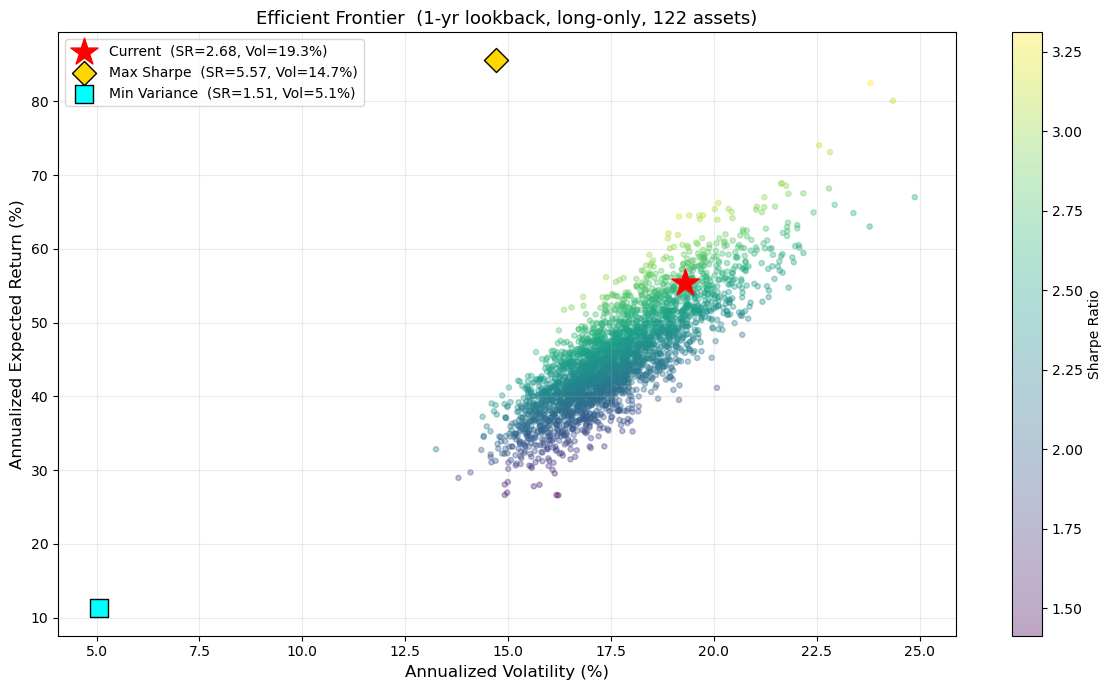

Saved /home/ai1/Documents/fiData/efficient_frontier.png

══════════════════════════════════════════════════════════════
  Optimized vs Current
══════════════════════════════════════════════════════════════
  Portfolio          Return      Vol   Sharpe
  --------------------------------------------
  Current            55.34%   19.30%    2.678
  Max Sharpe         85.65%   14.71%    5.575
  Min Variance       11.27%    5.05%    1.505

  Max-Sharpe weights > 1%:
XOM     21.69
ROST    12.25
SKT     10.73
AAPL     8.86
GOOG     8.72
WMT      7.86
SNDK     6.83
CBOE     6.08
COLO     4.80
STX      4.12
MU       2.36
INTC     2.23
GM       1.72
GLW      1.06


In [16]:

# ── Efficient Frontier (Monte Carlo + Optimization) ───────────────────────────
N_MC = 3000
rng  = np.random.default_rng(42)

mc_r, mc_v, mc_s = [], [], []
for _ in range(N_MC):
    w = rng.dirichlet(np.ones(n))
    r, v, s = port_stats(w)
    mc_r.append(r); mc_v.append(v); mc_s.append(s)

mc_r = np.array(mc_r) * 100
mc_v = np.array(mc_v) * 100
mc_s = np.array(mc_s)

# ── Max-Sharpe portfolio ──────────────────────────────────────────────────────
cons   = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}]
bounds = [(0.0, 1.0)] * n
w_init = np.ones(n) / n

def neg_sharpe(w):
    r, v, _ = port_stats(w)
    return -(r - rf_annual) / v if v > 0 else 1e6

def min_vol_fn(w):
    _, v, _ = port_stats(w)
    return v

opt_ms = minimize(neg_sharpe,  w_init, method='SLSQP', bounds=bounds,
                  constraints=cons, options={'maxiter': 2000, 'ftol': 1e-9})
w_ms = opt_ms.x
r_ms, v_ms, s_ms = port_stats(w_ms)

# ── Min-Variance portfolio ────────────────────────────────────────────────────
opt_mv = minimize(min_vol_fn, w_init, method='SLSQP', bounds=bounds,
                  constraints=cons, options={'maxiter': 2000, 'ftol': 1e-9})
w_mv = opt_mv.x
r_mv, v_mv, s_mv = port_stats(w_mv)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
sc = ax.scatter(mc_v, mc_r, c=mc_s, cmap='viridis', alpha=0.35, s=14, zorder=1)
plt.colorbar(sc, ax=ax, label='Sharpe Ratio')

ax.scatter(p_vol*100, p_ret*100, marker='*', s=420, color='red',
           zorder=5, label=f'Current  (SR={p_sr:.2f}, Vol={p_vol:.1%})')
ax.scatter(v_ms*100,  r_ms*100,  marker='D', s=150, color='gold',
           edgecolors='black', zorder=5,
           label=f'Max Sharpe  (SR={s_ms:.2f}, Vol={v_ms:.1%})')
ax.scatter(v_mv*100,  r_mv*100,  marker='s', s=150, color='cyan',
           edgecolors='black', zorder=5,
           label=f'Min Variance  (SR={s_mv:.2f}, Vol={v_mv:.1%})')

ax.set_xlabel('Annualized Volatility (%)', fontsize=12)
ax.set_ylabel('Annualized Expected Return (%)', fontsize=12)
ax.set_title(f'Efficient Frontier  (1-yr lookback, long-only, {n} assets)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.25)
plt.tight_layout()

EF_PATH = os.path.join(DATA_DIR, 'efficient_frontier.png')
plt.savefig(EF_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {EF_PATH}')

# ── Summary table ─────────────────────────────────────────────────────────────
print(f'\n{"═"*62}')
print(f'  Optimized vs Current')
print(f'{"═"*62}')
print(f'  {"Portfolio":<16} {"Return":>8} {"Vol":>8} {"Sharpe":>8}')
print(f'  {"-"*44}')
print(f'  {"Current":<16} {p_ret:>8.2%} {p_vol:>8.2%} {p_sr:>8.3f}')
print(f'  {"Max Sharpe":<16} {r_ms:>8.2%} {v_ms:>8.2%} {s_ms:>8.3f}')
print(f'  {"Min Variance":<16} {r_mv:>8.2%} {v_mv:>8.2%} {s_mv:>8.3f}')

print(f'\n  Max-Sharpe weights > 1%:')
ms_w = pd.Series(w_ms * 100, index=mpt_syms).round(2)
print(ms_w[ms_w > 1].sort_values(ascending=False).to_string())


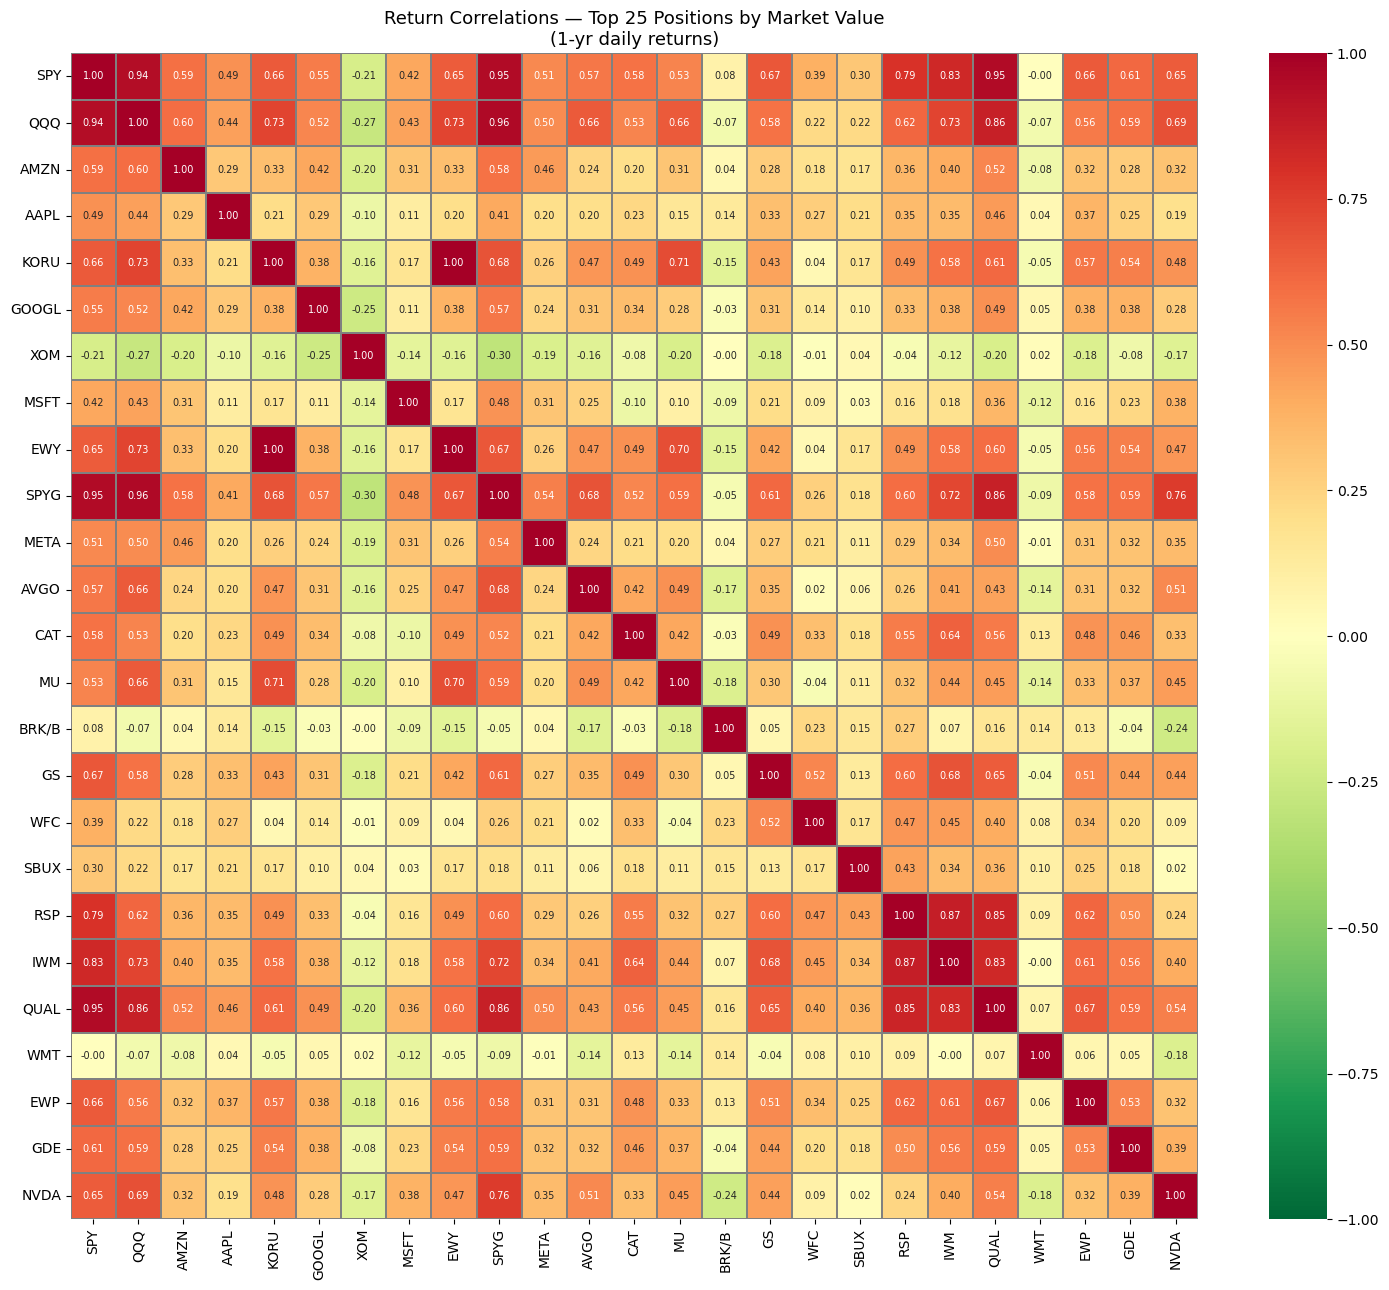

Saved /home/ai1/Documents/fiData/correlation_heatmap.png

  Pairs with |correlation| > 0.85:
  KORU     ↔ EWY       +1.00
  QQQ      ↔ SPYG      +0.96
  SPY      ↔ SPYG      +0.95
  SPY      ↔ QUAL      +0.95
  SPY      ↔ QQQ       +0.94
  RSP      ↔ IWM       +0.87
  QQQ      ↔ QUAL      +0.86
  SPYG     ↔ QUAL      +0.86


In [17]:

# ── Correlation Heatmap (top 25 positions by market value) ────────────────────
import seaborn as sns

TOP_N   = min(25, len(mpt_syms))
top_sym = combined.loc[mpt_syms, 'Market_Value'].nlargest(TOP_N).index.tolist()
corr    = rets[top_sym].corr().round(2)

fig, ax = plt.subplots(figsize=(15, 13))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdYlGn_r',
    vmin=-1, vmax=1, center=0,
    linewidths=0.3, linecolor='gray',
    annot_kws={'size': 7}, ax=ax,
)
ax.set_title(
    f'Return Correlations — Top {TOP_N} Positions by Market Value\n(1-yr daily returns)',
    fontsize=13,
)
plt.tight_layout()

CORR_PATH = os.path.join(DATA_DIR, 'correlation_heatmap.png')
plt.savefig(CORR_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {CORR_PATH}')

# ── Highly correlated pairs ────────────────────────────────────────────────────
THRESH = 0.85
high_corr = [
    (s1, s2, corr.loc[s1, s2])
    for i, s1 in enumerate(top_sym)
    for s2 in top_sym[i + 1:]
    if abs(corr.loc[s1, s2]) > THRESH
]
print(f'\n  Pairs with |correlation| > {THRESH}:')
if high_corr:
    for s1, s2, c in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f'  {s1:8s} ↔ {s2:8s}  {c:+.2f}')
else:
    print('  None found above threshold')
